## Advanced calibration methods and VIX derivatives
### Master M2MO, Université Paris Cité
### Master 2 Probabilités et Finance, Sorbonne Université and École polytechnique
# Computing assignment 

### Due Date: 11:59 PM Sunday, April 12, 2026

You should turn in the notebook on the Moodle course website. You are expected to work in groups of 3 preferably, or possibly groups of 2.

Please comment your code properly.

Before you turn in the notebook, press the "Run all cells" button in the toolbar, and make sure all the calculation results and graphs are produced correctly in a reasonable time frame, and then save the notebook under the name ComputingAssignmentACMVix-FirstName1LastName1-FirstName2LastName2-FirstName3LastName3.ipynb

<h3 style="color:deepskyblue">1. The Particle Method for Smile Calibration</h3>

Consider the stochastic local volatility (SLV) model

$$
\begin{array}{l}
dS_t = a_t l(t, S_t) S_t dW^{(1)}_t\\
a_t=\sigma_0 e^{Y_t}\quad\text{where}\quad d Y_t = -\kappa Y_tdt+\gamma dW^{(2)}_t\\
d \langle W^{(1)}, W^{(2)} \rangle_t = \rho dt.
\end{array}
$$

The numerical values for the model parameters are
- $T = 1$.
- $S_0 = 100$.
- $\sigma_0 = 15\%$.
- $Y_0 = 0$.
- $\rho = -50\%$.
- $\gamma = 50\%$.
- $\kappa = 1$.

The goal is to find a leverage function $l(t, S)$ so that this model matches the market prices of vanilla options. For the sake of simplicity, we assume that the market implied volatility surface is flat $\sigma_{\textrm{Market}} \equiv 15\%$. In that case, we also have $\sigma_{\textrm{Dup}}(t,S) \equiv 15\%$.

Below we describe a Monte Carlo simulation scheme for the SLV model.

First we discretize the interval $(0,T)$ into subintervals $(t_{i-1}, t_i)$, $1\leq i\leq n$, and set $\Delta t_i=t_i-t_{i-1}$. 

The Ornstein-Uhlenbeck process $Y$ is explicitly solvable:
\begin{equation}
Y_{t_i}=e^{-\kappa\Delta t_i}Y_{t_{i-1}}+\int_{t_{i-1}}^{t_i}\gamma e^{-\kappa\left(t_i-s\right)}dW_s^{(2)}.
\end{equation}

Therefore for given $Y_{t_{i-1}}$, $Y_{t_i}$ is a Gaussian variable with 
\begin{equation}\tag{1}
\mathbb{E}\left[\left.Y_{t_i}\right\vert Y_{t_{i-1}}\right]=e^{-\kappa\Delta t_i}Y_{t_{i-1}},\quad
\text{Var}\left[\left.Y_{t_i}\right\vert Y_{t_{i-1}}\right]=\frac{\gamma^2}{2\kappa}\left(1-e^{-2\kappa\Delta t_i}\right)
\end{equation}

so that paths of $Y$ can be simulated exactly.

To simulate the spot process $S$, we use the Euler scheme:
$$\log S_{t_i}-\log S_{t_{i-1}}=-\frac{1}{2}\sigma_0^2e^{2Y_{t_{i-1}}}l(t_{i-1},S_{t_{i-1}})^2\Delta t_i+\sigma_0 e^{Y_{t_{i-1}}}l(t_{i-1},S_{t_{i-1}})\int_{t_{i-1}}^{t_i}dW^{(1)}_t$$

Thus for given $S_{t_{i-1}}$ and $Y_{t_{i-1}}$, $\log S_{t_i}$ and $Y_{t_i}$ are jointly Gaussian variables with

\begin{equation}\tag{2}
\mathbb{E}\left[\left.\log S_{t_i}\right\vert S_{t_{i-1}},Y_{t_{i-1}}\right]=\log S_{t_{i-1}}-\frac{1}{2}\sigma_0^2e^{2Y_{t_{i-1}}}\Delta t_i,\quad\text{Var}\left[\left.\log S_{t_i}\right\vert S_{i_{i-1}}, Y_{t_{i-1}}\right]=\sigma_0^2e^{2Y_{t_{i-1}}}l(t_{i-1},S_{t_{i-1}})^2\Delta t_i
\end{equation}

\begin{equation}\tag{3}
\text{Cov}\left[\left.Y_{t_i},\log S_{t_i}\right\vert S_{t_{i-1}}, Y_{t_{i-1}}\right]=\sigma_0 e^{Y_{t_{i-1}}}l(t_{i-1},S_{t_{i-1}})\frac{\gamma\rho}{\kappa}\left(1-e^{-\kappa\Delta t_i}\right)
\quad\text{or}\quad
\text{Corr}\left[\left.Y_{t_i},\log S_{t_i}\right\vert S_{t_{i-1}}, Y_{t_{i-1}}\right]=\rho\sqrt{\frac{2(1-e^{-\kappa\Delta t_i})}{\kappa\Delta t_i(1+e^{-\kappa\Delta t_i})}}
\end{equation}

Over the time interval $[t_{i-1}, t_i]$, we can advance $\log S$ and $Y$ by generating Gaussian variables $\log S_{t_i}$ and $Y_{t_i}$ using equations (1)-(3). That is,

\begin{align}
\log S_{t_i} &= \log S_{t_{i-1}}-\frac{1}{2}\sigma_0^2e^{2Y_{t_{i-1}}}l(t_{i-1},S_{t_{i-1}})^2\Delta t_i+\sigma_0e^{Y_{t_{i-1}}}l(t_{i-1},S_{t_{i-1}})\sqrt{\Delta t_i}\left(\sqrt{1-\bar{\rho}^2}Z_1+\bar{\rho}Z_2\right),\quad\text{where }\bar{\rho}=\rho\sqrt{\frac{2(1-e^{-\kappa\Delta t_i})}{\kappa\Delta t_i(1+e^{-\kappa\Delta t_i})}}\\
Y_{t_i} &= e^{-\kappa\Delta t_i}Y_{t_{i-1}}+\gamma\sqrt{\frac{1-e^{-2\kappa\Delta t_i}}{2\kappa}}Z_2
\end{align}
where $Z_1$ and $Z_2$ are independent standard normal variables.

<b>(a).</b> Implementation of the Particle Method.
- Implement the particle method studied in class to find the leverage function $l$. We suggest that for the kernel regression you use the quartic kernel

$$\delta(x)=(x+1)^2(1-x)^2\quad\text{for }-1\leq x\leq 1\quad\text{and}\quad0\quad\text{ elsewhere}$$

together with the bandwidth 

$$h = \kappa \sigma_{\mathrm{Market}} S_0 \sqrt{\max(t_k,0.15)}N^{-0.2}$$

at discretization date $t_k$. We recall that the rescaled kernel is 

$$ \delta_h(x) = \frac{1}{h}\delta\left(\frac{x}{h}\right). $$

Make sure to fine-tune the dimensionless bandwidth parameter $\kappa$. Its order of magnitude is 1.0. Use $\Delta t = 1/100$, $N=10,000$ paths. Note: In class, we described an acceleration technique that involves sorting the "particles" $(S_{t_k},a_{t_k})$ according to the spot value $S_{t_k}$. Since the kernel we have chosen has compact support and is fairly inexpensive to evaluate, you may ignore this acceleration technique here. This means that each estimation of a conditional expectation $\mathbb{E}\left[\left.a_{t_k}^2\right\vert S_{t_k}=x\right]$ (for $x$ in a grid $G_{t_k}$ of spot values) involves the ratio of two sums of $N$ terms each. For the minimum and maximum values of $G_{t_k}$, take the 0.1% and 99.9% quantiles of the risk-neutral distribution of $S$ at $t_k$, i.e., since the smile is flat at $\sigma_{\textrm{Market}}$, of the distribution of $S_0\exp(\sigma_{\textrm{Market}}\sqrt{t_k}G - \frac12 \sigma_{\textrm{Market}}^2 t_k)$, with $G$ a standard Gaussian random variable. We suggest that the grid $G_{t_k}$ contain 30 equally spaced spot values.

- Check that the resulting model is indeed calibrated to the market implied volatilities $\sigma_{\textrm{Market}} \equiv 15\%$. To this end, compute estimates of the call prices (maturity $T=1$) in the calibrated model for strikes $70, 80, 90, 100, 110, 120, 130, 140$, and invert the Black-Scholes formula to get the corresponding estimation of the implied volatilities $\hat\sigma(T,K)$. To estimate the call prices in the calibrated model, simulate a new set of independent paths with the calibrated leverage function $l$ and $N_2 = 100,000$ paths. For the inversion of the Black-Scholes formula, you can use the function <code>blackscholes_impv</code> provided below.

<b>(b).</b> Fix the spot-vol correlation $\rho = 0\%$ and mean reversion $\kappa=1$. We study the impact of volatility of volatility $\gamma$ on the smile in the pure stochastic volatility model and calibrated leverage function in the SLV model. Perform the following tasks with various values of $\gamma$. Suggested values of $\gamma$: $0\%$, $25\%$, $50\%$, $75\%$.
- Recalibrate the leverage function $l(t,S)$ for each $\gamma$, and plot the calibrated leverage function $l(t, S)$ as a function of the spot value $S$ for a fixed maturity, e.g., $t = T$ with various values of $\gamma$ in the same graph. Comment on the dependence of the shape of the leverage function on $\gamma$.
- Plot the corresponding smile at maturity $T$ for the pure stochastic volatility model (set the leverage function $l \equiv 1$) with the various values of $\gamma$ in the same graph. Comment on the dependence of the shape of the smile on $\gamma$.

<b>(c).</b> Fix the volatility of volatility $\gamma = 50\%$ and mean reversion $\kappa=1$. We study the impact of spot-vol correlation $\rho$ on the smile in the pure stochastic volatility model and calibrated leverage function in the SLV model. Perform the following tasks with various values of $\rho$. Suggested values of $\rho$: $-50\%$, $0\%$, $50\%$.
- Recalibrate the leverage function $l(t,S)$ for each $\rho$, and plot the calibrated leverage function $l(t, S)$ as a function of the spot value $S$ for a fixed maturity, e.g., $t = T$ with various values of $\rho$ in the same graph. Comment on the dependence of the shape of the leverage function on $\rho$.
- Plot the corresponding smile at maturity $T$ for the pure stochastic volatility model (set the leverage function $l \equiv 1$) with the various values of $\rho$ in the same graph. Comment on the dependence of the shape of the smile on $\rho$.

<b>(d).</b> Fix the spot-vol correlation $\rho = 0\%$ and volatility of volatility $\gamma = 50\%$. We study the impact of mean reversion $\kappa$ on the smile in the pure stochastic volatility model and calibrated leverage function in the SLV model. Perform the following tasks with various values of $\kappa$. Suggested values of $\kappa$: $0.1$, $1$, $10$.
- Recalibrate the leverage function $l(t,S)$ for each $\gamma$, and plot the calibrated leverage function $l(t, S)$ as a function of the spot value $S$ for a fixed maturity, e.g., $t = T$ with various values of $\gamma$ in the same graph. Comment on the dependence of the shape of the leverage function on $\kappa$.
- Plot the corresponding smile at maturity $T$ for the pure stochastic volatility model (set the leverage function $l \equiv 1$) with the various values of $\kappa$ in the same graph. Comment on the dependence of the shape of the smile on $\kappa$.

<b>(e).</b> Consider the forward-starting call spread with payoff
\begin{equation*}
50 \left(\left( \frac{S_{T_2}}{S_{T_1}}-0.99 \right)_+ - \left( \frac{S_{T_2}}{S_{T_1}}-1.01 \right)_+\right)
\end{equation*}
with $T_1 = T - \frac{1}{12}$, $T_2 = T$. Use $\gamma = 100\%$, $\rho = -80\%$ and $\kappa=4$. Compare the prices of this option in the Black-Scholes model with volatility 15% and in the calibrated SLV model. Comment on the result. Why is it of interest to use stochastic local volatility models for pricing derivatives?

In [3]:
'Packages'
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [73]:
def blackscholes_price(K, T, S, vol, r=0, q=0, callput='call'):
    """Compute the call/put option price in Black-Scholes model
    
    Parameters
    ----------
    K: scalar or array_like
        The strike of the option.
    T: scalar or array_like
        The maturity of the option.
    S: scalar or array_like
        The spot price of the underlying security.
    vol: scalar or array_like
        The implied Black-Scholes volatility.
    callput: str
        Must be either 'call' or 'put'

    Returns
    -------
    price: scalar or array_like
        The price of the option.

    Examples
    --------
    >>> blackscholes_price(95, 0.25, 100, 0.2, r=0.05, callput='put')
    1.5342604771222823
    """
    F = S*np.exp((r-q)*T)
    w = vol**2*T
    d1 = (np.log(F/K)+0.5*w)/np.sqrt(w)
    d2 = d1 - np.sqrt(w)
    callput = callput.lower()
    if callput == 'call':
        opttype = 1
    elif callput == 'put':
        opttype = -1
    else:
        raise ValueError('The value of callput must be either "call" or "put".')
    price = (opttype*F*norm.cdf(opttype*d1)-opttype*K*norm.cdf(opttype*(d2)))*np.exp(-r*T)
    return price

In [5]:
# all inputs must be scalar
def blackscholes_impv_scalar(K, T, S, value, r=0, q=0, callput='call', tol=1e-6, maxiter=500):
    """Compute implied vol in Black-Scholes model
    
    Parameters
    ----------
    K: scalar
        The strike of the option.
    T: scalar
        The maturity of the option.
    S: scalar
        The spot price of the underlying security.
    value: scalar
        The value of the option
    callput: str
        Must be either 'call' or 'put'

    Returns
    -------
    vol: scalar
        The implied vol of the option.
    """
    if (K <= 0) or (T <= 0):
        return np.nan
    F = S*np.exp((r-q)*T)
    K = K/F
    value = value*np.exp(r*T)/F
    callput = callput.lower()
    if callput not in ['call', 'put']:
        raise ValueError('The value of "callput" must be either "call" or "put"')
    opttype = 1 if callput == 'call' else -1
    value -= max(opttype * (1 - K), 0)
    if value < 0:
        return np.nan
    if (value == 0):
        return 0
    j = 1
    p = np.log(K)
    if K >= 1:
        x0 = np.sqrt(2 * p)
        x1 = x0 - (0.5 - K * norm.cdf(-x0) - value) * np.sqrt(2*np.pi)
        while (abs(x0 - x1) > tol*np.sqrt(T)) and (j < maxiter):
            x0 = x1
            d1 = -p/x1+0.5*x1
            x1 = x1 - (norm.cdf(d1) - K*norm.cdf(d1-x1)-value)*np.sqrt(2*np.pi)*np.exp(0.5*d1**2)
            j += 1
        return x1 / np.sqrt(T)
    else:
        x0 = np.sqrt(-2 * p)
        x1 = x0 - (0.5*K-norm.cdf(-x0)-value)*np.sqrt(2*np.pi)/K
        while (abs(x0-x1) > tol*np.sqrt(T)) and (j < maxiter):
            x0 = x1
            d1 = -p/x1+0.5*x1
            x1 = x1-(K*norm.cdf(x1-d1)-norm.cdf(-d1)-value)*np.sqrt(2*np.pi)*np.exp(0.5*d1**2)
            j += 1
        return x1/np.sqrt(T)

# vectorized version
blackscholes_impv = np.vectorize(blackscholes_impv_scalar, excluded={'callput', 'tol', 'maxiter'})

# Example
blackscholes_impv(K=95, T=0.25, S=100, value=7, callput='call')

array(0.20654803)

In [6]:
def quartic_kernel(x):
    x = np.clip(x, -1, 1)
    return (x+1)**2*(1-x)**2

ANSWERS PART I BELOW

<b>(a).</b> Implementation of the Particle Method.

In [7]:
'Introduction of key parameters'
T = 1
S0 = 100
sigma0 = 0.15
Y0 = 0
rho = -0.5
gamma = 0.5
kappa = 1
a0 = sigma0 * np.exp(Y0)
Ndates= 100
t = np.linspace(0,T,Ndates+1)

def h(t_k,sigma_market = 0.15, kappa_band = 1, N = 10000, S0 = 100):
    return kappa*sigma_market*S0*np.sqrt(max(t_k,0.15)) * N**(-0.2)

In [8]:
'Constructing the grid'

Gmin = norm.ppf(0.001)
Gmax = norm.ppf(0.999)

grid = [None]

for k in range(1, len(t)):
    Smin = S0 * np.exp(sigma0 * np.sqrt(t[k]) * Gmin - 0.5 * sigma0**2 * t[k] )
    Smax = S0 * np.exp(sigma0 * np.sqrt(t[k]) * Gmax - 0.5 * sigma0**2 * t[k] )
    gridk = np.linspace(Smin, Smax, 30)
    grid.append(gridk)

In [ ]:
def calibrate_leverage(
    gamma,
    t,
    grid,
    S0,
    Y0,
    sigma0,
    rho,
    kappa,
    N=1000,
    T=1
):

    'Starting simulations'

    dt = T / 100
    sigma_market = 0.15

    S = [S0] * N
    Y = [Y0] * N
    a = [sigma0 * np.exp(Y0)] * N

    rhobar = rho * np.sqrt(2 * (1 - np.exp(-kappa * dt)) / (kappa * dt * (1 + np.exp(-kappa * dt))))

    l_values = [None] * len(t)
    l_values[0] = [1.0] * 30   #Initializing for t = 0


    'First step: t0 -> t1 (l = 1 evrywhere)'

    for i in range(N):
        Z1 = np.random.normal(0, 1)
        Z2 = np.random.normal(0, 1)
        Z = np.sqrt(1 - rhobar**2) * Z1 + rhobar * Z2

        Y_old = Y[i]
        S_old = S[i]
        a_old = sigma0 * np.exp(Y_old)

        Y[i] = np.exp(-kappa * dt) * Y_old + gamma * np.sqrt((1 - np.exp(-2 * kappa * dt)) / (2 * kappa)) * Z2
        logS_i = np.log(S_old) - 0.5 * (a_old**2) * dt + a_old * np.sqrt(dt) * Z
        S[i] = np.exp(logS_i)
        a[i] = sigma0 * np.exp(Y[i])


    'Main loop: build l(t_k, .), interpolate it, simulate to t_k+1'

    for k in range(1, len(t) - 1):

        # 1) estimate E[a^2 | S = x] on grid[k]
        EV_conditional_a = []
        hk = h(t[k], sigma_market=sigma_market, kappa_band=1.0, N=N, S0=S0)

        for x in grid[k]:
            numerator = 0.0
            denominator = 0.0

            for i in range(N):
                weight = (1 / hk) * quartic_kernel((S[i] - x) / hk)
                numerator += (a[i]**2) * weight
                denominator += weight

            if denominator > 0:
                EV_conditional_a.append(numerator / denominator)
            else:
                EV_conditional_a.append(sigma_market**2)

        # 2) leverage on grid[k]
        l_values[k] = [sigma_market / np.sqrt(value) for value in EV_conditional_a]

        # 3) simulate from t_k to t_k+1 using interpolated leverage
        for i in range(N):
            Z1 = np.random.normal(0, 1)
            Z2 = np.random.normal(0, 1)
            Z = np.sqrt(1 - rhobar**2) * Z1 + rhobar * Z2

            Y_old = Y[i]
            S_old = S[i]
            a_old = sigma0 * np.exp(Y_old)

            # interpolation of l(t_k, S_old)
            l_current = np.interp(S_old, grid[k], l_values[k], left=l_values[k][0], right=l_values[k][-1])

            Y[i] = np.exp(-kappa * dt) * Y_old + gamma * np.sqrt((1 - np.exp(-2 * kappa * dt)) / (2 * kappa)) * Z2
            logS_i = np.log(S_old) - 0.5 * (a_old**2) * (l_current**2) * dt + a_old * l_current * np.sqrt(dt) * Z
            S[i] = np.exp(logS_i)
            a[i] = sigma0 * np.exp(Y[i])


    'Finally: compute l at final maturity t_n as well'

    EV_conditional_a = []
    hk = h(t[-1], sigma_market=sigma_market, kappa_band=1.0, N=N, S0=S0)

    for x in grid[-1]:
        numerator = 0.0
        denominator = 0.0

        for i in range(N):
            weight = (1 / hk) * quartic_kernel((S[i] - x) / hk)
            numerator += (a[i]**2) * weight
            denominator += weight

        if denominator > 0:
            EV_conditional_a.append(numerator / denominator)
        else:
            EV_conditional_a.append(sigma_market**2)

    l_values[-1] = [sigma_market / np.sqrt(value) for value in EV_conditional_a]
    return l_values

Let's now test whether we have calibrated the volatility correctly by computing the prices of several calls

In [48]:
def simulate_terminal_spot(
    gamma,
    t,
    grid,
    S0,
    Y0,
    sigma0,
    rho,
    kappa,
    N=1000,
    N2=10000,
    T=1
):

    dt = T / 100

    # calibration du leverage
    l_values = calibrate_leverage(
        gamma,
        t,
        grid,
        S0=S0,
        Y0=Y0,
        sigma0=sigma0,
        rho=rho,
        kappa=kappa,
        N=N,
        T=T
    )

    S_MC = [S0] * N2
    Y_MC = [Y0] * N2

    rhobar = rho * np.sqrt(2 * (1 - np.exp(-kappa * dt)) / (kappa * dt * (1 + np.exp(-kappa * dt))))

    # simulation
    for k in range(len(t) - 1):

        for i in range(N2):

            Z1 = np.random.normal(0, 1)
            Z2 = np.random.normal(0, 1)
            Z = np.sqrt(1 - rhobar**2) * Z1 + rhobar * Z2

            Y_old = Y_MC[i]
            S_old = S_MC[i]
            a_old = sigma0 * np.exp(Y_old)

            if k == 0:
                l_current = 1.0
            else:
                l_current = np.interp(
                    S_old,
                    grid[k],
                    l_values[k],
                    left=l_values[k][0],
                    right=l_values[k][-1]
                )

            # update Y
            Y_MC[i] = np.exp(-kappa * dt) * Y_old + gamma * np.sqrt((1 - np.exp(-2 * kappa * dt)) / (2 * kappa)) * Z2

            # update S
            logS = np.log(S_old) - 0.5 * (a_old**2) * (l_current**2) * dt + a_old * l_current * np.sqrt(dt) * Z
            S_MC[i] = np.exp(logS)

    return S_MC

In [49]:
def impvd_volatility(
    gamma,
    t,
    grid,
    S0,
    Y0,
    sigma0,
    rho,
    kappa,
    N=1000,
    N2=10000,
    T=1
):

    S_MC = simulate_terminal_spot(
        gamma,
        t,
        grid,
        S0=S0,
        Y0=Y0,
        sigma0=sigma0,
        rho=rho,
        kappa=kappa,
        N=N,
        N2=N2,
        T=T
    )

    strikes = [70, 80, 90, 100, 110, 120, 130, 140]
    prices = [0] * len(strikes)

    # pricing
    for S in S_MC:
        for i in range(len(strikes)):
            prices[i] += max(0, S - strikes[i])

    for i in range(len(prices)):
        prices[i] *= 1 / N2

    # implied vols
    impvdict = {}

    for i in range(len(prices)):
        K = strikes[i]
        impvdict[K] = blackscholes_impv_scalar(
            K,
            T=T,
            S=S0,
            value=prices[i],
            r=0,
            q=0,
            callput='call'
        )

    return impvdict

In [51]:
res = impvd_volatility(0.5, 
    t, 
    grid,
    S0,
    Y0,
    sigma0,
    rho,
    kappa)

for K in res:
    print(K, res[K])

70 0.1879495503253405
80 0.15926845443889784
90 0.15119998440324067
100 0.15010933595354364
110 0.14978580386034668
120 0.1500412618683148
130 0.15208763678539136
140 0.15364983998110057


The results seem consistent regarding what we are expecting (15% for every strike). The NAN resulte for K = 70 may be linked to the fact that the impvd inverse function may stop if if ST-K is too small at some point.

Question 1b)

In [41]:
rho = 0

In [52]:
gammas = [0.0, 0.25, 0.5, 0.75]

for g in gammas:
    vols = impvd_volatility(g, 
    t, 
    grid,
    S0,
    Y0,
    sigma0,
    rho,
    kappa)
    print("gamma =", g)
    print(vols)

gamma = 0.0
{70: 0.22208110441075907, 80: 0.17694024864020422, 90: 0.1595152345934414, 100: 0.15371210957182796, 110: 0.15197379523658144, 120: 0.15057019908478864, 130: 0.14860095769153317, 140: 0.14917908366602006}
gamma = 0.25
{70: nan, 80: 0.12794576681320405, 90: 0.14454743002129947, 100: 0.14810975738438648, 110: 0.14962451888269188, 120: 0.14979314261660145, 130: 0.1495409468557851, 140: 0.14949734323118782}
gamma = 0.5
{70: 0.1848302283802281, 80: 0.15805987191575127, 90: 0.1523427836645242, 100: 0.15122877980274568, 110: 0.1524504253361125, 120: 0.15349117959835495, 130: 0.1536737524776049, 140: 0.1540642282633887}
gamma = 0.75
{70: 0.16626758800618854, 80: 0.1540753348685839, 90: 0.15112504453396772, 100: 0.14964396024945897, 110: 0.14785311605758528, 120: 0.14635000705007017, 130: 0.14792400896887684, 140: 0.1531606707163627}


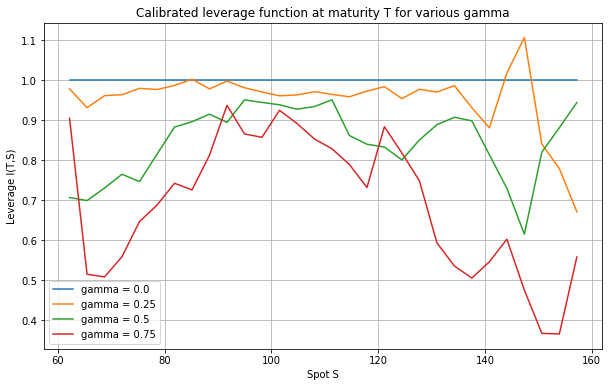

In [56]:
gammas = [0.0, 0.25, 0.5, 0.75]

plt.figure(figsize=(10, 6))

for g in gammas:
    l_values = calibrate_leverage(
        g,
        t,
        grid,
        S0,
        Y0,
        sigma0,
        rho,
        kappa = 1,
        N=1000,
        T=1
    )

    plt.plot(grid[-1], l_values[-1], label=f"gamma = {g}")

plt.xlabel("Spot S")
plt.ylabel("Leverage l(T,S)")
plt.title("Calibrated leverage function at maturity T for various gamma")
plt.legend()
plt.grid(True)
plt.show()

For gamma = 0, the leverage function is flat and close to 1, as expected since there is no stochastic volatility.
As gamma increases, the leverage function becomes more irregular and deviates more from 1, reflecting the increasing impact of stochastic volatility.
For larger gamma values, the estimated leverage function becomes noisier, especially in the wings, due to Monte Carlo noise and kernel estimation instability.
This effect is amplified by the relatively small number of simulated particles used for computational efficiency.

In [58]:
"Let's redo a function similar to the one of 1a) but with l = 1"

def simulate_terminal_spot_pure_sv(
    gamma,
    t,
    S0,
    Y0,
    sigma0,
    rho,
    kappa,
    N2=10000,
    T=1
):
    dt = T / 100

    S_MC = [S0] * N2
    Y_MC = [Y0] * N2

    rhobar = rho * np.sqrt(2 * (1 - np.exp(-kappa * dt)) / (kappa * dt * (1 + np.exp(-kappa * dt))))

    for k in range(len(t) - 1):
        for i in range(N2):
            Z1 = np.random.normal(0, 1)
            Z2 = np.random.normal(0, 1)
            Z = np.sqrt(1 - rhobar**2) * Z1 + rhobar * Z2

            Y_old = Y_MC[i]
            S_old = S_MC[i]
            a_old = sigma0 * np.exp(Y_old)

            # pure SV: leverage identically equal to 1
            l_current = 1

            # update Y
            Y_MC[i] = np.exp(-kappa * dt) * Y_old + gamma * np.sqrt((1 - np.exp(-2 * kappa * dt)) / (2 * kappa)) * Z2

            # update S
            logS = np.log(S_old) - 0.5 * (a_old**2) * dt + a_old * np.sqrt(dt) * Z
            S_MC[i] = np.exp(logS)

    return S_MC

In [59]:
def implied_volatility_pure_sv(
    gamma,
    t,
    S0,
    Y0,
    sigma0,
    rho,
    kappa,
    N2=10000,
    T=1
):
    S_MC = simulate_terminal_spot_pure_sv(
        gamma,
        t,
        S0,
        Y0,
        sigma0,
        rho,
        kappa,
        N2=N2,
        T=T
    )

    strikes = [70, 80, 90, 100, 110, 120, 130, 140]
    prices = [0] * len(strikes)

    for S in S_MC:
        for i in range(len(strikes)):
            prices[i] += max(0, S - strikes[i])

    for i in range(len(prices)):
        prices[i] *= 1 / N2

    impvdict = {}

    for i in range(len(prices)):
        K = strikes[i]
        impvdict[K] = blackscholes_impv_scalar(
            K,
            T=T,
            S=S0,
            value=prices[i],
            r=0,
            q=0,
            callput='call'
        )

    return impvdict

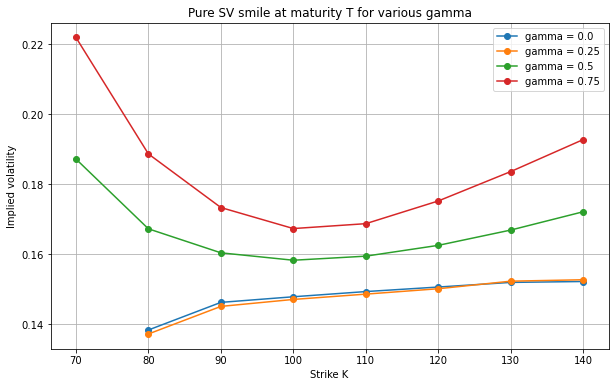

In [61]:
import matplotlib.pyplot as plt

gammas = [0.0, 0.25, 0.5, 0.75]

plt.figure(figsize=(10, 6))

for g in gammas:
    impvdict = implied_volatility_pure_sv(
        g,
        t,
        S0,
        Y0,
        sigma0,
        rho=0.0,   # imposed in question 1(b)
        kappa=1.0, # imposed in question 1(b)
        N2=10000,
        T=1
    )

    strikes = list(impvdict.keys())
    vols = list(impvdict.values())

    plt.plot(strikes, vols, marker='o', label=f"gamma = {g}")

plt.xlabel("Strike K")
plt.ylabel("Implied volatility")
plt.title("Pure SV smile at maturity T for various gamma")
plt.legend()
plt.grid(True)
plt.show()

For γ = 0, the model reduces to a deterministic volatility model, and the implied volatility surface is flat, as expected.
As γ increases, the volatility of volatility increases, introducing randomness in the instantaneous volatility.
This results in a mixture of lognormal distributions for the terminal spot, which generates a volatility smile.
The smile becomes more pronounced as γ increases.
Since ρ = 0, the smile is approximately symmetric around the at-the-money strike.

Question 1c

In [62]:
gamma = 0.5
kappa = 1

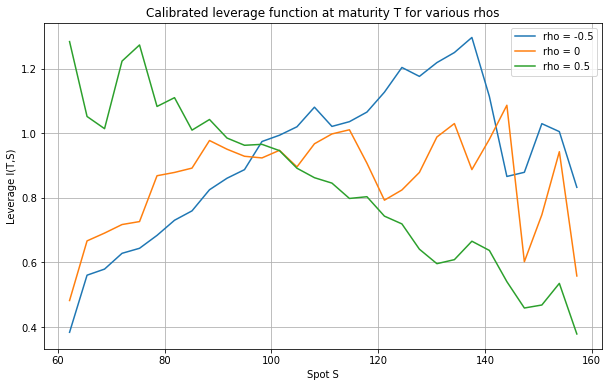

In [63]:
rhos = [-0.5, 0, 0.5]

plt.figure(figsize=(10, 6))

for r in rhos:
    l_values = calibrate_leverage(
        gamma,
        t,
        grid,
        S0,
        Y0,
        sigma0,
        r,
        kappa = 1,
        N=1000,
        T=1
    )

    plt.plot(grid[-1], l_values[-1], label=f"rho = {r}")

plt.xlabel("Spot S")
plt.ylabel("Leverage l(T,S)")
plt.title("Calibrated leverage function at maturity T for various rhos")
plt.legend()
plt.grid(True)
plt.show()

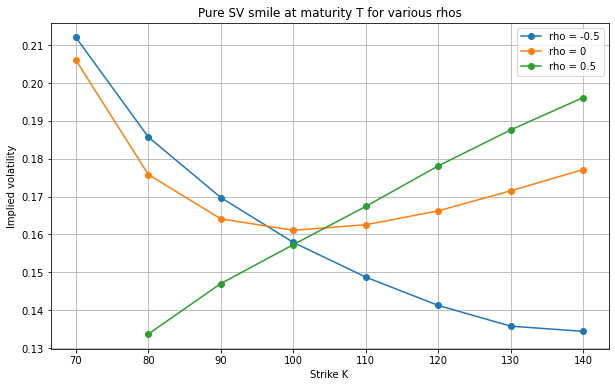

In [64]:
rhos = [-0.5, 0, 0.5]

plt.figure(figsize=(10, 6))

for r in rhos:
    impvdict = implied_volatility_pure_sv(
        gamma,
        t,
        S0,
        Y0,
        sigma0,
        rho=r,   
        kappa=1,
        N2=10000,
        T=1
    )

    strikes = list(impvdict.keys())
    vols = list(impvdict.values())

    plt.plot(strikes, vols, marker='o', label=f"rho = {r}")

plt.xlabel("Strike K")
plt.ylabel("Implied volatility")
plt.title("Pure SV smile at maturity T for various rhos")
plt.legend()
plt.grid(True)
plt.show()


For rho = 0, the pure stochastic volatility model generates a roughly symmetric smile.
For negative rho, the smile becomes a decreasing skew, which is the standard equity pattern.
For positive rho, the skew is reversed and implied volatility increases with strike.

Question 1d

In [65]:
rho = 0
gamma = 0.5

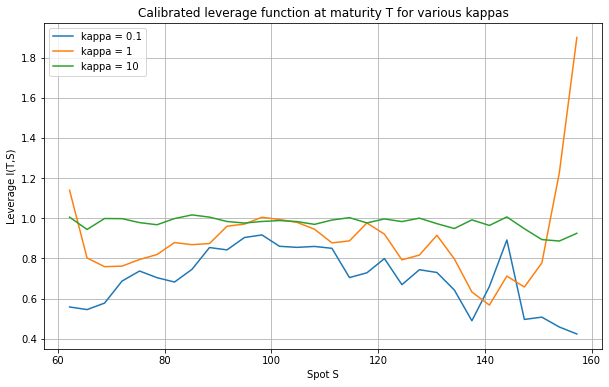

In [66]:
kappas = [0.1,1,10]

plt.figure(figsize=(10, 6))

for k in kappas:
    l_values = calibrate_leverage(
        gamma,
        t,
        grid,
        S0,
        Y0,
        sigma0,
        rho,
        kappa = k,
        N=1000,
        T=1
    )

    plt.plot(grid[-1], l_values[-1], label=f"kappa = {k}")

plt.xlabel("Spot S")
plt.ylabel("Leverage l(T,S)")
plt.title("Calibrated leverage function at maturity T for various kappas")
plt.legend()
plt.grid(True)
plt.show()

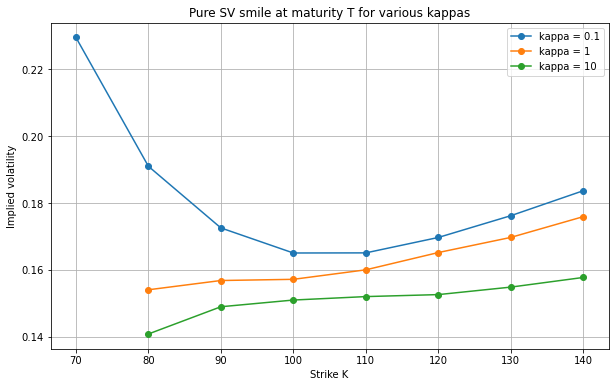

In [67]:
kappas = [0.1,1,10]

plt.figure(figsize=(10, 6))

for k in kappas:
    impvdict = implied_volatility_pure_sv(
        gamma,
        t,
        S0,
        Y0,
        sigma0,
        rho,   
        kappa=k,
        N2=10000,
        T=1
    )

    strikes = list(impvdict.keys())
    vols = list(impvdict.values())

    plt.plot(strikes, vols, marker='o', label=f"kappa = {k}")

plt.xlabel("Strike K")
plt.ylabel("Implied volatility")
plt.title("Pure SV smile at maturity T for various kappas")
plt.legend()
plt.grid(True)
plt.show()

The parameter kappa controls the speed of mean reversion of the volatility process.
For small kappa, volatility is highly persistent, leading to a larger dispersion of future variance and a pronounced volatility smile.
As kappa increases, volatility reverts more quickly to its mean, reducing the variability of the instantaneous variance and thus flattening the smile.
For large kappa, the model behaves close to a constant volatility model, and the implied volatility surface becomes nearly flat.
The calibrated leverage function reflects this effect: it becomes flatter as kappa increases.

Question 1e

Let's first compute the Black & Scholes price of the option which payoff is 
\begin{equation*}
50 \left(\left( \frac{S_{T_2}}{S_{T_1}}-0.99 \right)_+ - \left( \frac{S_{T_2}}{S_{T_1}}-1.01 \right)_+\right)
\end{equation*}
with $T_1 = T - \frac{1}{12}$, $T_2 = T$. Use $\gamma = 100\%$, $\rho = -80\%$ and $\kappa=4$

Under Black & Scholes assumptions, we use the fact that
\begin{equation*}
\frac{S_{T_2}}{S_{T_1}}, \frac{S_{T_2 - T_1} }{S_{0}} 
\end{equation*} 
have the same distribution. We can therefore use the Black & Scholes function already implemented.

In [76]:

T = 1/12
S0 = 1
K_low = 0.99
K_high = 1.01
sigma0 = 15/100

In [77]:
print("Black & Scholes Price", 50 * (blackscholes_price(K_low, T, S0, sigma0, r=0, q=0, callput='call') - blackscholes_price(K_high, T, S0, sigma0, r=0, q=0, callput='call')))

Black & Scholes Price 0.4915905629509276


<h3 style="color:deepskyblue">2. Pricing SPX options, VIX futures and VIX options in the two-factor Bergomi model</h3>

The objective of this second part of the computing assignment is to price SPX options, VIX futures, and VIX options in the two-factor Bergomi model

\begin{eqnarray}
S_t &=& S_0 \exp\left(\int_0^t \sqrt{\xi_s^s}dW_s - \frac{1}{2}\int_0^t \xi_s^s ds \right) \\
    X_t^j &=& e^{-k_j t} \int_0^t e^{k_j s} \, dZ^j_s, \qquad j\in\{1,2\} \\
\alpha_\theta &=& \left( (1-\theta)^2 +\theta^2+2 \rho_{12}\theta(1-\theta)\right)^{-1/2} \\
x_t^u &=& \alpha_\theta \left((1-\theta)e^{-k_1(u-t)}X_t^1 + \theta e^{-k_2(u-t)}X_t^2 \right) \\
\xi_t^u &=& \xi_0^u g^u(t,x_t^u) \;\; = \;\;\xi_0^u f^u(t,X_t^1,X_t^2) \\
g^u(t,x) &=& \exp\left(\omega x - \frac{\omega^2}{2}\chi(t,u)\right) \\
\chi(t,u) &=& \alpha_\theta^2\left( (1-\theta)^2e^{-2k_1(u-t)} \text{Var}(X_t^1) + \theta^2e^{-2k_2(u-t)} \text{Var}(X_t^2) \right. \\
&& \left. + 2\theta(1-\theta)e^{-(k_1+k_2)(u-t)}\text{Cov}(X_t^1,X_t^2)\right) \\
d\langle W,Z^1\rangle_t &=& \rho_{S1} dt \\
d\langle W,Z^2\rangle_t &=& \rho_{S2} dt \\
d\langle Z^1,Z^2\rangle_t &=& \rho_{12} dt \\
\end{eqnarray}

In [10]:
import numpy as np

from scipy.stats import norm
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (4.8, 3.2)

from math import exp, sqrt, log, pi, sin, cos, atan, tan

In [11]:
from py_vollib.black_scholes.implied_volatility import implied_volatility
vec_find_vol_rat = np.vectorize(implied_volatility)   # a better imp vol estimator based on P Jäckel Let's be rational

ModuleNotFoundError: No module named 'py_vollib'

## Pricing SPX options

1. By doing a Cholesky decomposition, give a necessary and sufficient condition (*) on $\rho_{S1},\rho_{S2},\rho_{12}$ so that
$$\begin{bmatrix}1 & \rho_{S1} & \rho_{S2}\\ \rho_{S1} & 1 & \rho_{12} \\ \rho_{S2} & \rho_{12} & 1\end{bmatrix}$$
is a correlation matrix.

Below we describe a Monte Carlo simulation scheme for the two-factor Bergomi model.

First we discretize the interval $(0,T)$ into subintervals $(t_{i-1}, t_i)$, $1\leq i\leq n$, and set $\Delta t_i=t_i-t_{i-1}$. 

The Ornstein-Uhlenbeck process $X^j$ is explicitly solvable:
\begin{equation}
X^j_{t_i}=e^{-k_j\Delta t_i}X^j_{t_{i-1}}+\int_{t_{i-1}}^{t_i} e^{-k_j\left(t_i-s\right)}dZ_s^{j}.
\end{equation}
so that paths of $X^j$ can be simulated exactly.

To simulate the spot process $S$, we use the Euler scheme on the log (by abuse of notation, below, S will denote the Euler scheme, not the true asset price process):
$$\log S_{t_i}-\log S_{t_{i-1}}=-\frac{1}{2}\xi_{t_{i-1}}^{t_{i-1}}\Delta t_i+\sqrt{\xi_{t_{i-1}}^{t_{i-1}}}\int_{t_{i-1}}^{t_i}dW_t$$

Thus given $(S_{t_{i-1}},X^1_{t_{i-1}},X^2_{t_{i-1}})$, $(\log S_{t_i},X^1_{t_i},X^2_{t_i})$ is a Gaussian vector.

2. Compute the mean vector and covariance matrix of this Gaussian vector.

This is what we will use to iteratively simulate $(\log S_{t_i},X^1_{t_i},X^2_{t_i})$.

3. Fill in the blanks in the code below.


In [ ]:
def two_factor_bergomi_mc(vov,k_1,k_2,theta,rho_sx1,rho_sx2,rho_x1x2,xi_0,n_steps,N_sims):
    #xi_0 is assumed costant: just a number
    #vov is the vol of variance omega

    tt = np.linspace(0., T, n_steps + 1)
    dt = T/n_steps
    
    def covar(k_1,k_2,rho,t): 

        return rho*(1-np.exp(-(k_1+k_2)*t))/(k_1+k_2)
        
    def chi_func(k_1,k_2,theta,rho_x1x2,alpha,t): # computes chi(t,t)
        chi = (1-theta)**2*covar(k_1,k_1,1.0,t)+theta**2*covar(k_2,k_2,1.0,t)+\
        2*theta*(1-theta)*covar(k_1,k_2,rho_x1x2,t)
    
        return alpha**2*chi
    
    alpha = 1/sqrt((1-theta)**2+theta**2+2*rho_x1x2*theta*(1-theta))
    chi = chi_func(k_1,k_2,theta,rho_x1x2,alpha,tt)
    
    X_1 = np.zeros((n_steps+1,N_sims))
    X_2 = np.zeros((n_steps+1,N_sims))
    X = np.zeros((n_steps+1,N_sims))
    inst_vol = np.zeros((n_steps+1,N_sims))
    logS = np.zeros((n_steps+1,N_sims))
    logS[0] = log(S_0)
    inst_vol[0] = sqrt(xi_0)

    for i in range(n_steps):
        z1, z2, z3 = np.random.normal(size=(3,N_sims))
        X_1[i+1] = X_1[i]*np.exp(-k_1*dt) + sqrt(covar(k_1,k_1,1,dt))*z1
        X_2[i+1] = ...
        X[i+1] = alpha*((1-theta)*X_1[i+1] + theta*X_2[i+1])
        inst_vol[i+1] = sqrt(xi_0)*np.exp(vov*X[i+1]/2-vov**2/4*chi[i+1])
    
        logS[i+1] = ...
        
    return np.exp(logS[-1])

In [ ]:
vov = 4 
k_1 = 20
k_2 = 1.5
theta = 0.75
xi_0 = 0.025
rho_sx1,rho_sx2,rho_x1x2 = -0.8, -0.7, 0.7
T = 1

In [ ]:
S_0 = 100

In [ ]:
n_steps = 500
N_sims = 100000

In [ ]:
ST = two_factor_bergomi_mc(vov,k_1,k_2,theta,rho_sx1, rho_sx2, rho_x1x2,xi_0,n_steps,N_sims)

In [ ]:
lm = np.linspace(-0.6,0.4,100) # log-moneyness
strike_array = np.exp(lm)*S_0

In [ ]:
opt_price = np.average(np.maximum(ST-strike_array.reshape(-1,1),0),axis=1)
iv = vec_find_vol_rat(opt_price, S_0, strike_array, T, 0, 'c')

In [ ]:
plt.plot(strike_array,opt_price)
plt.grid()

In [ ]:
plt.plot(lm,iv)
plt.grid()

4. Vary the parameters vov, k_1, k_2, theta, rho_sx1, rho_sx2, rho_x1x2 and T and comment on the impact on the SPX smile.

## Pricing VIX futures and VIX options

5. Prove that $(\xi_t^u)_{t\in[0,u]}$ is a martingale in $t$, for fixed $u>0$.
Denote $\sigma_t^2 = \xi_t^t$. Prove that $\xi_T^u = \mathbb{E}[\sigma_u^2|\mathcal{F}_T]$ and deduce that
$$\text{VIX}^2_T = \frac{1}{\tau}\int_T^{T+\tau} \xi_T^u du$$
where $\tau=30/365$ (30 days). Prove that, as a result, in the two-factor Bergomi model, there exists a function $\psi$ such that
$$\text{VIX}_T = \psi(T,X_T^1,X_T^2)$$
and write down the function $\psi$.

Since the vector $(X_T^1,X_T^2)$ is Gaussian, the price $\mathbb{E}[h(\text{VIX}_T)]$ of a VIX option $h(\text{VIX}_T)$ can very efficiently be estimated by a Gauss-Hermite quadrature; see 
https://en.wikipedia.org/wiki/Gaussian_quadrature and 
https://numpy.org/doc/stable/reference/generated/numpy.polynomial.hermite.hermgauss.html

6. Using this method, price a VIX future maturing at $T$ (choose $T=1/12$ (1 month), $2/12$, $3/12$, $4/12$) and VIX call options with the same maturity; take strikes with log-moneyness from -0.2 to 2.5, based on the price of the VIX future. Vary the number of points in the quadrature: 10, 20, 30, 50. What do you observe? Using 50 points in the quadrature, plot the VIX smile, using the Black formula (with spot value the value of the VIX future) to compute the VIX implied volatilities.

7. Comment on the impact of the vol-of-vol on the price of the VIX future and on the VIX implied volatilities. In the one-factor Bergomi model ($\theta=0$), comment on the impact of the mean reversion on the VIX implied volatilities: take $k_1 = 1,5,10,30,60,100$.